## Basic Data summary

library("tidyverse")

In [17]:
ad_data <- read.csv("../Datasets/Advertising.csv")
glimpse(ad_data)

Rows: 200
Columns: 5
$ X         <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1…
$ TV        <dbl> 230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 8.6, 199.…
$ radio     <dbl> 37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6, 2.1, 2.6, 5.…
$ newspaper <dbl> 69.2, 45.1, 69.3, 58.5, 58.4, 75.0, 23.5, 11.6, 1.0, 21.2, 2…
$ sales     <dbl> 22.1, 10.4, 9.3, 18.5, 12.9, 7.2, 11.8, 13.2, 4.8, 10.6, 8.6…


In [54]:
head(ad_data)

,TV,radio,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2


In [21]:
class(ad_data)

[1] "data.frame"

In [20]:
dim(ad_data)

[1] 200   4

In [19]:
names(ad_data)

[1] "TV"        "radio"     "newspaper" "sales"

In [26]:
ad_data <- select(ad_data, TV:sales)

In [27]:
head(ad_data)

,TV,radio,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2


In [31]:
attach(ad_data)

In [33]:
sum(is.na(ad_data))

[1] 0

## Visualization

In [34]:
library(GGally)

Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2



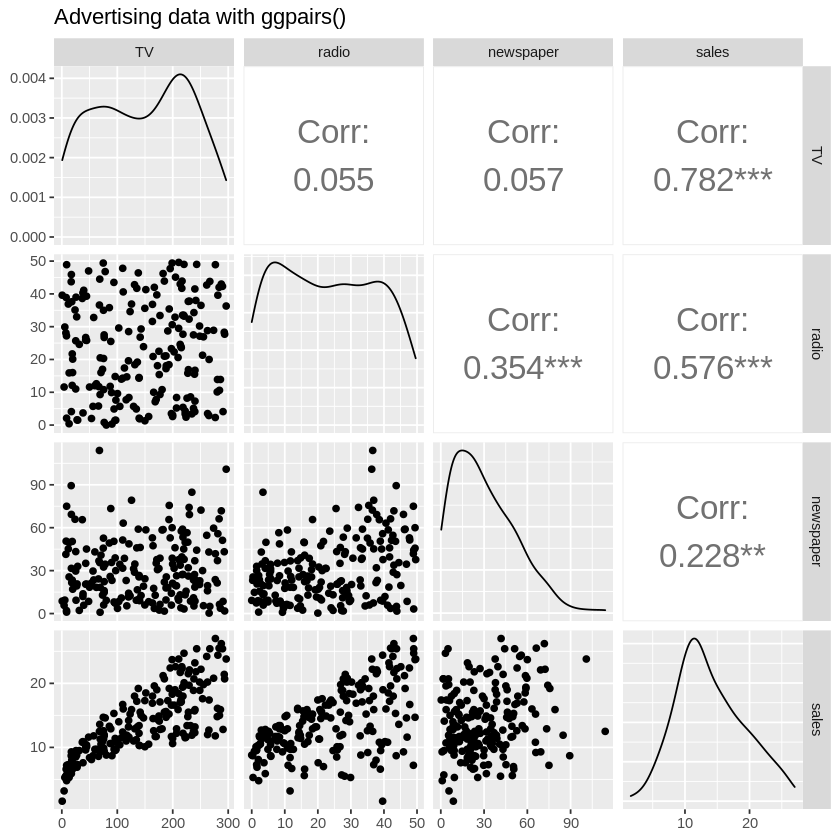

In [36]:
ggpairs(data = ad_data, title = "Advertising data with ggpairs()", upper = list(continuous = wrap("cor", size = 7)))

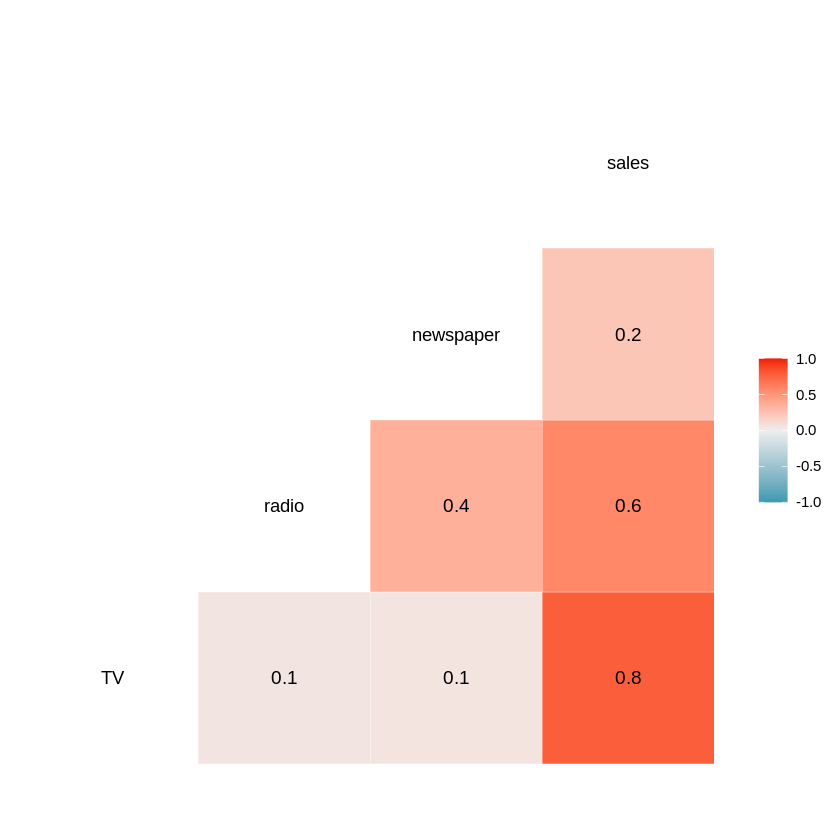

In [44]:
ggcorr(data = ad_data, method = c('everything', 'pearson'), label = TRUE)

In [49]:
corr <- cor(ad_data)
round(corr, 2)
round(corr[,"sales"], 2)

,TV,radio,newspaper,sales
TV,1.00,0.05,0.06,0.78
radio,0.05,1.00,0.35,0.58
newspaper,0.06,0.35,1.00,0.23
sales,0.78,0.58,0.23,1.00


TV     radio newspaper     sales 
     0.78      0.58      0.23      1.00

## Linear Regression Modelling

#### Building a simple linear model

In [51]:
ad_model <- lm(ad_data$sales ~ ., data = ad_data)
ad_model


Call:
lm(formula = ad_data$sales ~ ., data = ad_data)

Coefficients:
(Intercept)           TV        radio    newspaper  
   2.938889     0.045765     0.188530    -0.001037  


In [53]:
summary(ad_model)


Call:
lm(formula = ad_data$sales ~ ., data = ad_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8277 -0.8908  0.2418  1.1893  2.8292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.938889   0.311908   9.422   <2e-16 ***
TV           0.045765   0.001395  32.809   <2e-16 ***
radio        0.188530   0.008611  21.893   <2e-16 ***
newspaper   -0.001037   0.005871  -0.177     0.86    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.686 on 196 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8956 
F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16


#### Model and Calc check for values TV = 100, radio = 20, newspaper = 10

In [55]:
calc_value <- 2.938 + 0.046 * 100 + 0.188 * 20 + (-0.001) * 10
calc_value

[1] 11.288

In [56]:
model_value <- predict(ad_model, data.frame(TV = 100, radio = 20, newspaper = 10))
model_value

1 
11.27558

#### Linear Modelling in practice

In [58]:
library(caret)

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




In [59]:
set.seed(998)

In [62]:
trainR <- createDataPartition(ad_data$sales, p = 0.80, list = FALSE)
nrow(ad_data)
nrow(trainR)

[1] 200

[1] 162

In [65]:
train_data <- ad_data[ trainR,]
test_data <- ad_data[ -trainR,]
head(train_data)
head(test_data)

,TV,radio,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
7,57.5,32.8,23.5,11.8


,TV,radio,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
6,8.7,48.9,75.0,7.2
15,204.1,32.9,46.0,19.0
16,195.4,47.7,52.9,22.4
28,240.1,16.7,22.9,15.9
40,228.0,37.7,32.0,21.5
44,206.9,8.4,26.4,12.9


In [68]:
fit_control <- trainControl(method = 'cv', number = 10)
ad_model_2 <- train(sales ~ ., data = ad_data, method = 'lm', trControl = fit_control)
ad_model_2

Linear Regression 

200 samples
  3 predictor

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 179, 180, 179, 180, 181, 180, ... 
Resampling results:

  RMSE      Rsquared   MAE     
  1.656699  0.9023305  1.279775

Tuning parameter 'intercept' was held constant at a value of TRUE

In [69]:
summary(ad_model_2)


Call:
lm(formula = .outcome ~ ., data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8277 -0.8908  0.2418  1.1893  2.8292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.938889   0.311908   9.422   <2e-16 ***
TV           0.045765   0.001395  32.809   <2e-16 ***
radio        0.188530   0.008611  21.893   <2e-16 ***
newspaper   -0.001037   0.005871  -0.177     0.86    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.686 on 196 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8956 
F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16


In [72]:
model_value_2 <- predict(ad_model_2, data.frame(TV = 100, radio = 20, newspaper = 10))
model_value_2

1 
11.27558